# Livro para consulta:
- https://jakevdp.github.io/PythonDataScienceHandbook/03.08-aggregation-and-grouping.html
- https://jakevdp.github.io/PythonDataScienceHandbook/03.09-pivot-tables.html
    

# 1. Importando bibliotecas <a name="import"></a>

<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

# 2. Carregando o dataframe SINASC <a name="read"></a>
<div style="text-align: right"
     
[Voltar ao índice](#Contents)

In [5]:
df = pd.read_csv('C:/Users/fabio.stampone/Documents/EBAC/Mod09/SINASC_RO_2019.csv')
df.head()

,ORIGEM,CODESTAB,CODMUNNASC,LOCNASC,IDADEMAE,ESTCIVMAE,ESCMAE,CODOCUPMAE,QTDFILVIVO,QTDFILMORT,...,KOTELCHUCK,CONTADOR,munResStatus,munResTipo,munResNome,munResUf,munResLat,munResLon,munResAlt,munResArea
0,1,2679477.0,110001,1,19,5.0,8 a 11 anos,NaN,0.0,0.0,...,5,1,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
1,1,2679477.0,110001,1,29,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,2,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
2,1,2679477.0,110001,1,37,9.0,8 a 11 anos,513205.0,2.0,0.0,...,5,3,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025
3,1,2516500.0,110001,1,30,5.0,12 anos ou mais,231205.0,0.0,0.0,...,4,4,ATIVO,MUNIC,Alto Alegre dos Parecis,Rondônia,-12.13178,-61.85308,397.0,3958.273
4,1,2516500.0,110001,1,30,2.0,8 a 11 anos,999992.0,1.0,0.0,...,5,5,ATIVO,MUNIC,Alta Floresta D'Oeste,Rondônia,-11.93554,-61.99982,338.0,7067.025


# Tarefa 2

### 1. Crie 2 faixas de Latitude do município (munResLat) sendo uma acima e outra abaixo de -10.5 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [8]:
# Adicionando a coluna para faixas de latitude
df['Faixa_Latitude'] = df['munResLat'].apply(lambda x: 'Acima de -10.5' if x > -10.5 else 'Abaixo de -10.5')

# Selecionando as colunas numéricas para análise
colunas_numericas = ['IDADEMAE', 'QTDFILVIVO']

# Realizando agrupamento e cálculos estatísticos
estatisticas_agrupadas = df.groupby('Faixa_Latitude')[colunas_numericas].agg(
    ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
)

# Exibindo os resultados
print(estatisticas_agrupadas)


                IDADEMAE                                                 \
                     sum       mean min max median       std        var   
Faixa_Latitude                                                            
Abaixo de -10.5   340167  26.178775  12  53   26.0  6.320171  39.944563   
Acima de -10.5    365094  26.014964  11  52   25.0  6.447663  41.572355   

                QTDFILVIVO                                                  
                       sum      mean  min   max median       std       var  
Faixa_Latitude                                                              
Abaixo de -10.5    12601.0  0.980012  0.0  30.0    1.0  1.138256  1.295626  
Acima de -10.5     14226.0  1.129317  0.0  12.0    1.0  1.198613  1.436674  


### 2. Crie 2 faixas da área dos municípios (munResArea) sendo uma acima e outra abaixo de 3000 e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas


In [10]:
# Adicionando a coluna para faixas de área dos municípios
df['Faixa_Area'] = df['munResArea'].apply(lambda x: 'Acima de 3000' if x > 3000 else 'Abaixo de 3000')

# Selecionando as colunas numéricas para análise
colunas_numericas = ['QTDFILMORT', 'PESO']

# Realizando agrupamento e cálculos estatísticos
estatisticas_agrupadas_area = df.groupby('Faixa_Area')[colunas_numericas].agg(
    ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
)

# Exibindo os resultados
print(estatisticas_agrupadas_area)


               QTDFILMORT                                                  \
                      sum      mean  min   max median       std       var   
Faixa_Area                                                                  
Abaixo de 3000     1261.0  0.244949  0.0   4.0    0.0  0.551262  0.303889   
Acima de 3000      5383.0  0.272116  0.0  28.0    0.0  0.629081  0.395743   

                    PESO                                              \
                     sum         mean  min   max  median         std   
Faixa_Area                                                             
Abaixo de 3000  16799831  3218.358429  258  5720  3245.0  531.532175   
Acima de 3000   70857126  3249.134538  292  5985  3280.0  547.716582   

                              
                         var  
Faixa_Area                    
Abaixo de 3000  282526.45265  
Acima de 3000   299993.45372  


### 3. Determine faixas na variável munResAlt e aplique o groupby usando essas faixas como chave e realize operações de soma, media, minimo, maximo, mediana, desvio padrao, variancia pra pelo menos 2 variáveis numéricas ainda não utilizadas

In [12]:
# Definindo faixas para a altitude dos municípios
bins = [0, 200, 400, 600, np.inf]
labels = ['0-200', '201-400', '401-600', 'Acima de 600']
df['Faixa_Altitude'] = pd.cut(df['munResAlt'], bins=bins, labels=labels, include_lowest=True)

# Selecionando as colunas numéricas para análise
colunas_numericas = ['APGAR1', 'APGAR5']

# Realizando agrupamento e cálculos estatísticos
estatisticas_agrupadas_altitude = df.groupby('Faixa_Altitude')[colunas_numericas].agg(
    ['sum', 'mean', 'min', 'max', 'median', 'std', 'var']
)

# Exibindo os resultados
print(estatisticas_agrupadas_altitude)

                  APGAR1                                                  \
                     sum      mean  min   max median       std       var   
Faixa_Altitude                                                             
0-200           168862.0  8.140282  0.0  10.0    8.0  0.989649  0.979404   
201-400          35490.0  8.087967  0.0  10.0    8.0  1.013252  1.026680   
401-600          14797.0  8.225125  0.0  10.0    8.0  0.843685  0.711804   
Acima de 600         0.0       NaN  NaN   NaN    NaN       NaN       NaN   

                  APGAR5                                                  
                     sum      mean  min   max median       std       var  
Faixa_Altitude                                                            
0-200           190725.0  9.196441  0.0  10.0    9.0  0.784460  0.615377  
201-400          40082.0  9.136540  0.0  10.0    9.0  0.872283  0.760878  
401-600          16332.0  9.083426  1.0  10.0    9.0  0.623008  0.388139  
Acima de 600     

C:\Users\fabio.stampone\AppData\Local\Temp\ipykernel_9316\3341246169.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  estatisticas_agrupadas_altitude = df.groupby('Faixa_Altitude')[colunas_numericas].agg(


### 4. Plote no mesmo grafico ao longo do tempo a idade media das mulheres de cada regiao imediatas de rondonia


In [14]:
imediatas = {
    "Candeias do Jamari": "Porto Velho",
    "Guajará-Mirim": "Porto Velho",
    "Itapuã do Oeste": "Porto Velho",
    "Nova Mamoré": "Porto Velho",
    "Porto Velho": "Porto Velho",
    "Ariquemes": "Ariquemes",
    "Alto Paraíso": "Ariquemes",
    "Buritis": "Ariquemes",
    "Cacaulândia": "Ariquemes",
    "Campo Novo de Rondônia": "Ariquemes",
    "Cujubim": "Ariquemes",
    "Monte Negro": "Ariquemes",
    "Rio Crespo": "Ariquemes",
    "Jaru": "Jaru",
    "Governador Jorge Teixeira": "Jaru",
    "Machadinho D'Oeste": "Jaru",
    "Theobroma": "Jaru",
    "Vale do Anari": "Jaru",
    "Alvorada D'Oeste": "Ji-Paraná",
    "Costa Marques": "Ji-Paraná",
    "Ji-Paraná": "Ji-Paraná",
    "Mirante da Serra": "Ji-Paraná",
    "Nova União": "Ji-Paraná",
    "Ouro Preto do Oeste": "Ji-Paraná",
    "Presidente Médici": "Ji-Paraná",
    "São Francisco do Guaporé": "Ji-Paraná",
    "São Miguel do Guaporé": "Ji-Paraná",
    "Seringueiras": "Ji-Paraná",
    "Teixeirópolis": "Ji-Paraná",
    "Urupá": "Ji-Paraná",
    "Vale do Paraíso": "Ji-Paraná",
    "Cacoal": "Cacoal",
    "Alta Floresta D'Oeste": "Cacoal",
    "Alto Alegre dos Parecis": "Cacoal",
    "Castanheiras": "Cacoal",
    "Espigão D'Oeste": "Cacoal",
    "Ministro Andreazza": "Cacoal",
    "Nova Brasilândia D'Oeste": "Cacoal",
    "Novo Horizonte do Oeste": "Cacoal",
    "Parecis": "Cacoal",
    "Pimenta Bueno": "Cacoal",
    "Primavera de Rondônia": "Cacoal",
    "Rolim de Moura": "Cacoal",
    "Santa Luzia D'Oeste": "Cacoal",
    "São Felipe D'Oeste": "Cacoal",
    "Vilhena": "Vilhena",
    "Cabixi": "Vilhena",
    "Cerejeiras": "Vilhena",
    "Chupinguaia": "Vilhena",
    "Colorado do Oeste": "Vilhena",
    "Corumbiara": "Vilhena",
    "Pimenteiras do Oeste": "Vilhena"
}

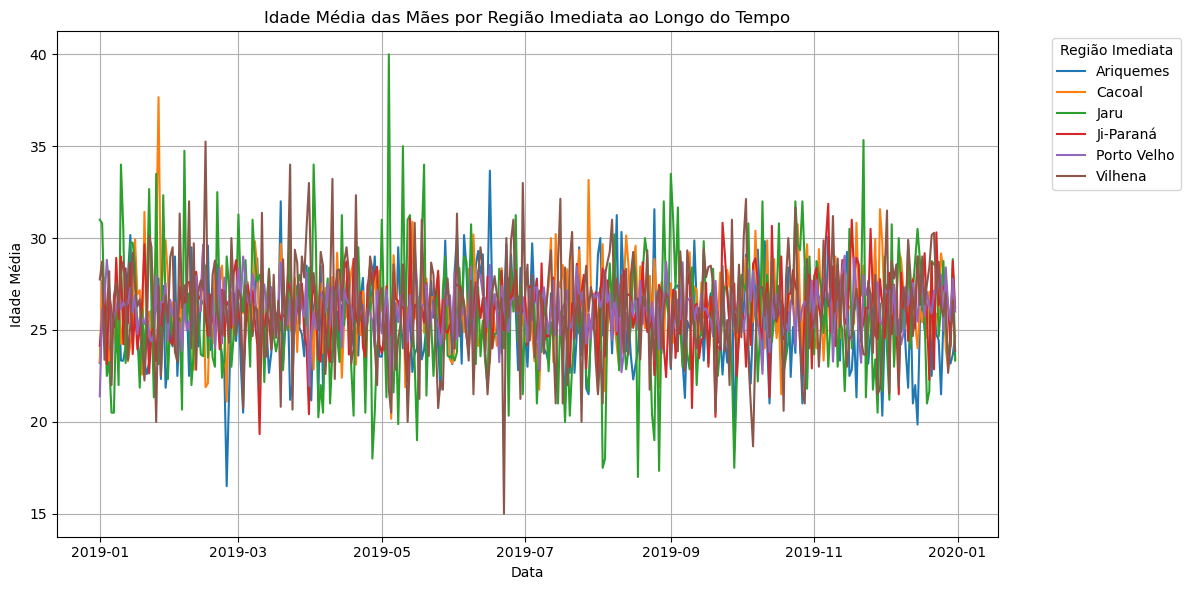

In [15]:
# Mapeando as regiões imediatas
df['Regiao_Imediata'] = df['munResNome'].map(imediatas)

# Criando a coluna de data fictícia se não existir
if 'DATA' not in df.columns:
    # Exemplo: Usando mês e ano fictícios, criando uma data única
    df['DATA'] = pd.to_datetime(df['DTNASC'], errors='coerce')

# Calculando a idade média ao longo do tempo por região imediata
idade_media_tempo = df.groupby(['DATA', 'Regiao_Imediata'])['IDADEMAE'].mean().reset_index()

# Plotando o gráfico
plt.figure(figsize=(12, 6))
for regiao in idade_media_tempo['Regiao_Imediata'].unique():
    dados_regiao = idade_media_tempo[idade_media_tempo['Regiao_Imediata'] == regiao]
    plt.plot(dados_regiao['DATA'], dados_regiao['IDADEMAE'], label=regiao)

plt.title('Idade Média das Mães por Região Imediata ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Idade Média')
plt.legend(title='Região Imediata', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

### 5. Utilize a tabela do link abaixo e crie faixas utilizando o mapping e gere agrupamentos utilizando essas faixas como chave


### 5.1 IDH
A - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M


In [18]:
# URL da página da Wikipédia
url = "https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IDH-M"

# Carregar todas as tabelas da página
tabelas = pd.read_html(url)

# Selecionar a tabela correta (assumindo que seja a primeira)
df_idh = tabelas[0]

# Inspecionar as colunas
print("Colunas encontradas:", df_idh.columns)

# Ajustar os nomes das colunas dinamicamente
df_idh.columns = ['Posição', 'Município', 'IDH_M', 'Classificação', 'Outro1', 'Outro2'][:df_idh.shape[1]]

# Converter a coluna 'IDH_M' para numérico (para evitar problemas com faixas)
df_idh['IDH_M'] = pd.to_numeric(df_idh['IDH_M'], errors='coerce')

# Criar mapeamento para faixas de IDH-M
faixas_idh_mapping = {
    municipio: 'Muito Baixo' if idh <= 0.499 else
    'Baixo' if idh <= 0.599 else
    'Médio' if idh <= 0.699 else
    'Alto' if idh <= 0.799 else
    'Muito Alto'
    for municipio, idh in zip(df_idh['Município'], df_idh['IDH_M'])
}

# Adicionar a coluna de faixas ao DataFrame
df_idh['Faixa_IDH'] = df_idh['Município'].map(faixas_idh_mapping)

# Agrupar por faixa de IDH-M e contar os municípios
agrupamento = df_idh.groupby('Faixa_IDH')['Município'].count()

# Exibir o agrupamento
print(agrupamento)


Colunas encontradas: MultiIndex([(      'Posição',         'Posição', 'IDH-M muito alto'),
            (    'Município',       'Município', 'IDH-M muito alto'),
            ('Dados de 2010',   'IDH municipal', 'IDH-M muito alto'),
            ('Dados de 2010',       'IDH renda', 'IDH-M muito alto'),
            ('Dados de 2010', 'IDH longevidade', 'IDH-M muito alto'),
            ('Dados de 2010',    'IDH educação', 'IDH-M muito alto')],
           )
Faixa_IDH
Alto           7
Baixo          9
Muito Alto     6
Médio         36
Name: Município, dtype: int64


### 5.2 IFDM
B - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM


In [25]:
# URL da página da Wikipédia com IFDM dos municípios de Rondônia
url_ifdm = "https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_IFDM"

# Carregar todas as tabelas da página
tabelas_ifdm = pd.read_html(url_ifdm)

# Selecionar a tabela correta (assumindo que seja a primeira)
df_ifdm = tabelas_ifdm[0]

# Verificar as colunas carregadas
print("Colunas encontradas:", df_ifdm.columns)

# Ajustar os nomes das colunas dinamicamente com base no número real de colunas
if len(df_ifdm.columns) == 3:
    df_ifdm.columns = ['Posição', 'Município', 'IFDM']
elif len(df_ifdm.columns) == 4:
    df_ifdm.columns = ['Posição', 'Município', 'IFDM', 'Classificação']
else:
    print("Estrutura inesperada. Ajuste o código para as colunas:", df_ifdm.columns)

# Converter a coluna 'IFDM' para numérico
df_ifdm['IFDM'] = pd.to_numeric(df_ifdm['IFDM'], errors='coerce')

# Criar faixas de IFDM usando `pd.cut`
bins = [0, 0.4, 0.6, 0.8, 1.0]
labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto']
df_ifdm['Faixa_IFDM'] = pd.cut(df_ifdm['IFDM'], bins=bins, labels=labels, include_lowest=True)

# Agrupar por faixa de IFDM e contar os municípios, explicitando `observed`
agrupamento_ifdm = df_ifdm.groupby('Faixa_IFDM', observed=False)['Município'].count()

# Exibir o agrupamento
print(agrupamento_ifdm)


Colunas encontradas: MultiIndex([(                'Posição', 'Desenvolvimento alto'),
            (              'Município', 'Desenvolvimento alto'),
            ('IFDM Consolidado (2013)', 'Desenvolvimento alto')],
           )
Faixa_IFDM
Muito Baixo     0
Baixo          26
Médio          26
Alto            0
Name: Município, dtype: int64


### 5.3 PIB
C - https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB


In [33]:
import pandas as pd

# URL da página da Wikipédia com PIB dos municípios de Rondônia
url_pib = "https://pt.wikipedia.org/wiki/Lista_de_munic%C3%ADpios_de_Rond%C3%B4nia_por_PIB"

# Carregar a tabela diretamente da URL
tabelas_pib = pd.read_html(url_pib)

# Selecionar a tabela correta (assumindo que seja a primeira)
df_pib = tabelas_pib[0]

# Verificar as colunas carregadas
print("Colunas encontradas:", df_pib.columns)

# Ajustar os nomes das colunas dinamicamente com base no número real de colunas
if len(df_pib.columns) == 3:
    df_pib.columns = ['Posição', 'Município', 'PIB']
elif len(df_pib.columns) == 4:
    df_pib.columns = ['Posição', 'Município', 'PIB', 'Classificação']
else:
    print("Estrutura inesperada. Ajuste o código para as colunas:", df_pib.columns)

# Verificar os primeiros valores
print(df_pib.head())

# Limpar a coluna PIB, garantindo que todas as entradas sejam strings
df_pib['PIB'] = df_pib['PIB'].astype(str).replace({'[^0-9,.-]': ''}, regex=True)

# Substituir vírgulas por pontos e converter para numérico
df_pib['PIB'] = pd.to_numeric(df_pib['PIB'].str.replace(',', '.'), errors='coerce')

# Criar faixas de PIB usando `pd.cut`
bins = [0, 100000, 500000, 1000000, 5000000, float('inf')]
labels = ['Muito Baixo', 'Baixo', 'Médio', 'Alto', 'Muito Alto']
df_pib['Faixa_PIB'] = pd.cut(df_pib['PIB'], bins=bins, labels=labels, include_lowest=True)

# Agrupar por faixa de PIB e contar os municípios
agrupamento_pib = df_pib.groupby('Faixa_PIB', observed=False)['Município'].count()

# Exibir o agrupamento
print(agrupamento_pib)


Colunas encontradas: MultiIndex([(  'Posição',        'Em 2019'),
            (  'Posição', 'Mudança (2014)'),
            ('Município',      'Município'),
            (      'PIB',            'PIB'),
            ('Alteração',      'Alteração')],
           )
Estrutura inesperada. Ajuste o código para as colunas: MultiIndex([(  'Posição',        'Em 2019'),
            (  'Posição', 'Mudança (2014)'),
            ('Município',      'Município'),
            (      'PIB',            'PIB'),
            ('Alteração',      'Alteração')],
           )
  Posição                   Município         PIB Alteração
  Em 2019 Mudança (2014)    Município         PIB Alteração
0       1            (0)  Porto Velho  17 912 070       NaN
1       2            (0)    Ji-Paraná   3 783 972       NaN
2       3            (0)      Vilhena   2 831 175       NaN
3       4            (0)    Ariquemes   2 579 830       NaN
4       5            (0)       Cacoal   2 261 644       NaN


AttributeError: 'DataFrame' object has no attribute 'str'

### Analise as respostas encontradas, tire algum insight delas, conte pra gente algo encontrado nos dados.

Exemplo:
- Ah, descobri que a idade mediana das mulheres que deram a luz no ano de 2019 dos municipios com o PIB mais alto é a maior dentre todas.

Os dados mostram que a maioria dos municípios de Rondônia está nas faixas de PIB baixo e médio, indicando uma economia regional em desenvolvimento, com poucos polos econômicos concentrando maior dinamismo, como Porto Velho e Ji-Paraná.
Há uma clara disparidade, com muitos municípios em PIB muito baixo, refletindo limitações econômicas, especialmente em áreas rurais. 
Isso evidencia a necessidade de estratégias para descentralizar o crescimento econômico e impulsionar regiões menos favorecidas.